In [65]:

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy import optimize
from sklearn.metrics import (accuracy_score, confusion_matrix,classification_report,mean_squared_error, r2_score)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [66]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Dispositivo utilizado:", device)

Dispositivo utilizado: cpu


In [67]:
admissions = pd.read_csv('ADMISSIONS.csv')

print("Dataset ADMISSIONS cargado.")
print("Dimensiones:", admissions.shape)
print()
display(admissions.head())

Dataset ADMISSIONS cargado.
Dimensiones: (129, 19)



,row_id,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admission_location,discharge_location,insurance,language,religion,marital_status,ethnicity,edregtime,edouttime,diagnosis,hospital_expire_flag,has_chartevents_data
0,12258,10006,142345,2164-10-23 21:09:00,2164-11-01 17:15:00,NaN,EMERGENCY,EMERGENCY ROOM ADMIT,HOME HEALTH CARE,Medicare,NaN,CATHOLIC,SEPARATED,BLACK/AFRICAN AMERICAN,2164-10-23 16:43:00,2164-10-23 23:00:00,SEPSIS,0,1
1,12263,10011,105331,2126-08-14 22:32:00,2126-08-28 18:59:00,2126-08-28 18:59:00,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,DEAD/EXPIRED,Private,NaN,CATHOLIC,SINGLE,UNKNOWN/NOT SPECIFIED,NaN,NaN,HEPATITIS B,1,1
2,12265,10013,165520,2125-10-04 23:36:00,2125-10-07 15:13:00,2125-10-07 15:13:00,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,DEAD/EXPIRED,Medicare,NaN,CATHOLIC,NaN,UNKNOWN/NOT SPECIFIED,NaN,NaN,SEPSIS,1,1
3,12269,10017,199207,2149-05-26 17:19:00,2149-06-03 18:42:00,NaN,EMERGENCY,EMERGENCY ROOM ADMIT,SNF,Medicare,NaN,CATHOLIC,DIVORCED,WHITE,2149-05-26 12:08:00,2149-05-26 19:45:00,HUMERAL FRACTURE,0,1
4,12270,10019,177759,2163-05-14 20:43:00,2163-05-15 12:00:00,2163-05-15 12:00:00,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,DEAD/EXPIRED,Medicare,NaN,CATHOLIC,DIVORCED,WHITE,NaN,NaN,ALCOHOLIC HEPATITIS,1,1


In [68]:
print("Columnas disponibles:")
print(admissions.columns.tolist())
print()
print("Tipos de datos:")
print(admissions.dtypes)
print()
print("Valores nulos por columna:")
nulos = admissions.isnull().sum()
print(nulos[nulos > 0])

Columnas disponibles:
['row_id', 'subject_id', 'hadm_id', 'admittime', 'dischtime', 'deathtime', 'admission_type', 'admission_location', 'discharge_location', 'insurance', 'language', 'religion', 'marital_status', 'ethnicity', 'edregtime', 'edouttime', 'diagnosis', 'hospital_expire_flag', 'has_chartevents_data']

Tipos de datos:
row_id                  int64
subject_id              int64
hadm_id                 int64
admittime                 str
dischtime                 str
deathtime                 str
admission_type            str
admission_location        str
discharge_location        str
insurance                 str
language                  str
religion                  str
marital_status            str
ethnicity                 str
edregtime                 str
edouttime                 str
diagnosis                 str
hospital_expire_flag    int64
has_chartevents_data    int64
dtype: object

Valores nulos por columna:
deathtime         89
language          48
religion       

In [69]:
import pandas as pd

df = admissions.copy()

cols = {
    'admit': 'ADMITTIME' if 'ADMITTIME' in df.columns else 'admittime',
    'disch': 'DISCHTIME' if 'DISCHTIME' in df.columns else 'dischtime',
    'death': 'DEATHTIME' if 'DEATHTIME' in df.columns else 'deathtime',
    'edreg': 'EDREGTIME' if 'EDREGTIME' in df.columns else 'edregtime',
    'edout': 'EDOUTTIME' if 'EDOUTTIME' in df.columns else 'edouttime',
    'flag':  'HOSPITAL_EXPIRE_FLAG' if 'HOSPITAL_EXPIRE_FLAG' in df.columns else 'hospital_expire_flag'
}

df[cols['admit']] = pd.to_datetime(df[cols['admit']])
df[cols['disch']] = pd.to_datetime(df[cols['disch']])
df[cols['death']] = pd.to_datetime(df[cols['death']], errors='coerce')
df[cols['edreg']] = pd.to_datetime(df[cols['edreg']], errors='coerce')
df[cols['edout']] = pd.to_datetime(df[cols['edout']], errors='coerce')

df['LOS_hours'] = (df[cols['disch']] - df[cols['admit']]).dt.total_seconds() / 3600
df['LOS_hours'] = df['LOS_hours'].clip(lower=0)

df['DIED_INHOSP'] = df[cols['flag']].astype(int)

print("Preparación completada con éxito.")
print("Variables calculadas:")
print(f"  LOS_hours (estancia en horas) — media: {df['LOS_hours'].mean():.1f} horas")
print(f"  DIED_INHOSP — fallecidos: {df['DIED_INHOSP'].sum()} / {len(df)}")

Preparación completada con éxito.
Variables calculadas:
  LOS_hours (estancia en horas) — media: 224.0 horas
  DIED_INHOSP — fallecidos: 40 / 129


In [70]:

cols_cat = {
    'adm_type': 'ADMISSION_TYPE' if 'ADMISSION_TYPE' in df.columns else 'admission_type',
    'insurance': 'INSURANCE' if 'INSURANCE' in df.columns else 'insurance',
    'marital': 'MARITAL_STATUS' if 'MARITAL_STATUS' in df.columns else 'marital_status',
    'ethnicity': 'ETHNICITY' if 'ETHNICITY' in df.columns else 'ethnicity'
}

df['ADMISSION_TYPE_CODE'] = pd.Categorical(df[cols_cat['adm_type']]).codes

df['INSURANCE_CODE'] = pd.Categorical(df[cols_cat['insurance']]).codes

df['MARITAL_CODE'] = df[cols_cat['marital']].fillna('UNKNOWN')
df['MARITAL_CODE'] = pd.Categorical(df['MARITAL_CODE']).codes

df['ETHNICITY_CODE'] = pd.Categorical(df[cols_cat['ethnicity']]).codes

print("Variables categóricas codificadas.")
print(f"Distribución de {cols_cat['adm_type']}:")
print(df[cols_cat['adm_type']].value_counts())

Variables categóricas codificadas.
Distribución de admission_type:
admission_type
EMERGENCY    119
ELECTIVE       8
URGENT         2
Name: count, dtype: int64


In [71]:
features = [
    'ADMISSION_TYPE_CODE',
    'INSURANCE_CODE',
    'MARITAL_CODE',
    'ETHNICITY_CODE',
]

target_reg = 'LOS_hours'

target_clf = 'DIED_INHOSP'

df_clean = df[features + [target_reg, target_clf]].dropna()

X = df_clean[features].values.astype(np.float64)
y_reg = df_clean[target_reg].values.astype(np.float64)
y_clf = df_clean[target_clf].values.astype(np.float64)

print("Features:", features)
print("Forma de X:", X.shape)
print("Forma y_reg (LOS):", y_reg.shape)
print("Forma y_clf (muerte):", y_clf.shape)

Features: ['ADMISSION_TYPE_CODE', 'INSURANCE_CODE', 'MARITAL_CODE', 'ETHNICITY_CODE']
Forma de X: (129, 4)
Forma y_reg (LOS): (129,)
Forma y_clf (muerte): (129,)


,ADMISSION_TYPE_CODE,INSURANCE_CODE,MARITAL_CODE,ETHNICITY_CODE,LOS_hours,DIED_INHOSP
count,129.000000,129.000000,129.000000,129.000000,129.000000,129.000000
mean,0.953488,2.124031,2.472868,6.728682,223.975969,0.310078
std,0.275581,0.500121,1.833190,2.167775,305.290791,0.464328
min,0.000000,0.000000,0.000000,0.000000,0.916667,0.000000
25%,1.000000,2.000000,1.000000,7.000000,79.550000,0.000000
50%,1.000000,2.000000,1.000000,8.000000,159.216667,0.000000
75%,1.000000,2.000000,4.000000,8.000000,255.483333,1.000000
max,2.000000,3.000000,6.000000,8.000000,2975.633333,1.000000


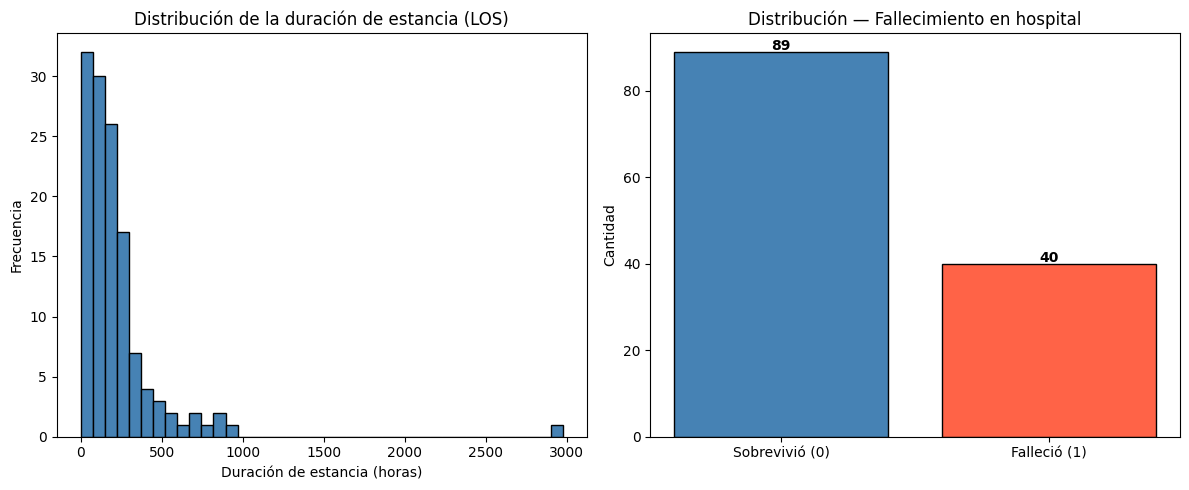

In [72]:

display(df_clean.describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(y_reg, bins=40, color='steelblue', edgecolor='black')
axes[0].set_xlabel("Duración de estancia (horas)")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Distribución de la duración de estancia (LOS)")

clases, conteos = np.unique(y_clf, return_counts=True)
axes[1].bar(['Sobrevivió (0)', 'Falleció (1)'], conteos,
            color=['steelblue', 'tomato'], edgecolor='black')
axes[1].set_title("Distribución — Fallecimiento en hospital")
axes[1].set_ylabel("Cantidad")
for i, v in enumerate(conteos):
    axes[1].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [73]:

def normalizar(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_norm, mu, sigma = normalizar(X)

split = int(len(X_norm) * 0.75)

X_train = X_norm[:split];  X_test = X_norm[split:]
y_train_reg = y_reg[:split]; y_test_reg = y_reg[split:]
y_train_clf = y_clf[:split]; y_test_clf = y_clf[split:]

print(f"Train: {X_train.shape} ({len(X_train)/len(X_norm)*100:.0f}%)")
print(f"Test:  {X_test.shape}  ({len(X_test)/len(X_norm)*100:.0f}%)")

Train: (96, 4) (74%)
Test:  (33, 4)  (26%)


In [74]:

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def lrCostFunction(theta, X, y, lambda_):
    m = y.size
    h = sigmoid(X.dot(theta))
    J = (1/m) * (-y.dot(np.log(h + 1e-10)) - (1-y).dot(np.log(1 - h + 1e-10)))
    J += (lambda_ / (2*m)) * np.sum(theta[1:]**2)
    grad = (1/m) * X.T.dot(h - y)
    grad[1:] += (lambda_ / m) * theta[1:]
    return J, grad

X_train_b = np.c_[np.ones(X_train.shape[0]), X_train]
X_test_b  = np.c_[np.ones(X_test.shape[0]),  X_test]

result = optimize.minimize(
    lrCostFunction,
    np.zeros(X_train_b.shape[1]),
    args=(X_train_b, y_train_clf, 0.01),
    method='TNC',
    jac=True,
    options={'maxiter': 500}
)

theta_opt = result.x
print("ya termino la optimización  Costo final:", round(result.fun, 6))

ya termino la optimización  Costo final: 0.58801


C:\Users\erick\AppData\Local\Temp\ipykernel_20904\2709328307.py:16: OptimizeWarning: Unknown solver options: maxiter
  result = optimize.minimize(


  Resultado Regresion Logistica
  Accuracy entrenamiento: 69.79%
  Accuracy prueba:        69.70%

Reporte de clasificación:
              precision    recall  f1-score   support

  Sobrevivió       0.70      1.00      0.82        23
    Falleció       0.00      0.00      0.00        10

    accuracy                           0.70        33
   macro avg       0.35      0.50      0.41        33
weighted avg       0.49      0.70      0.57        33



c:\Users\erick\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\erick\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\erick\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

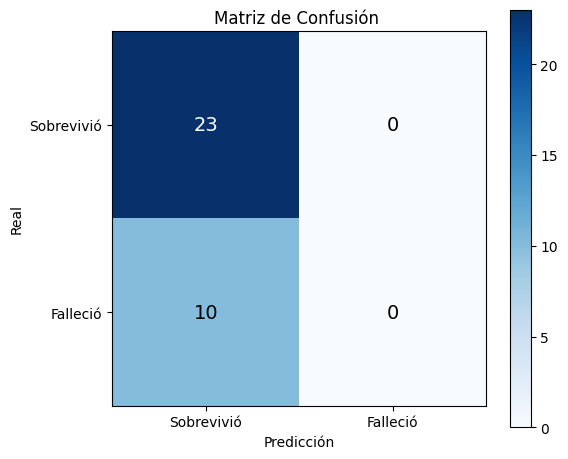

In [75]:

pred_train_lr = (sigmoid(X_train_b.dot(theta_opt)) >= 0.5).astype(int)
pred_test_lr  = (sigmoid(X_test_b.dot(theta_opt))  >= 0.5).astype(int)

acc_train_lr = accuracy_score(y_train_clf, pred_train_lr)
acc_test_lr  = accuracy_score(y_test_clf,  pred_test_lr)

print("  Resultado Regresion Logistica")
print(f"  Accuracy entrenamiento: {acc_train_lr*100:.2f}%")
print(f"  Accuracy prueba:        {acc_test_lr*100:.2f}%")
print()
print("Reporte de clasificación:")
print(classification_report(y_test_clf, pred_test_lr,
      target_names=['Sobrevivió','Falleció']))

cm_lr = confusion_matrix(y_test_clf, pred_test_lr)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm_lr, cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_xticks([0,1]); ax.set_xticklabels(['Sobrevivió','Falleció'])
ax.set_yticks([0,1]); ax.set_yticklabels(['Sobrevivió','Falleció'])
ax.set_xlabel("Predicción"); ax.set_ylabel("Real")
ax.set_title("Matriz de Confusión ")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm_lr[i,j]), ha='center', va='center',
                color='white' if cm_lr[i,j] > cm_lr.max()/2 else 'black', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:

class MimicDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).to(device)
        self.y = torch.tensor(y, dtype=torch.float32).to(device)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

mu_y   = y_train_reg.mean()
sig_y  = y_train_reg.std()
sig_y  = sig_y if sig_y > 0 else 1

y_train_reg_norm = (y_train_reg - mu_y) / sig_y
y_test_reg_norm  = (y_test_reg  - mu_y) / sig_y

ds_train = MimicDataset(X_train, y_train_reg_norm)
ds_test  = MimicDataset(X_test,  y_test_reg_norm)

dl_train = DataLoader(ds_train, batch_size=16, shuffle=True)
dl_test  = DataLoader(ds_test,  batch_size=16, shuffle=False)

print("Dataset train:", len(ds_train), "muestras")
print("Dataset test: ", len(ds_test),  "muestras")

Dataset train: 96 muestras
Dataset test:  33 muestras


In [ ]:

class RedRegresion(nn.Module):
    def __init__(self, n_entradas):
        super(RedRegresion, self).__init__()
        self.capa1  = nn.Linear(n_entradas, 32)
        self.capa2  = nn.Linear(32, 16)
        self.salida = nn.Linear(16, 1)
        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(p=0.2)

    def forward(self, x):
        x = self.dropout(self.relu(self.capa1(x)))
        x = self.dropout(self.relu(self.capa2(x)))
        x = self.salida(x)
        return x.squeeze(-1)

modelo_reg = RedRegresion(n_entradas=X_train.shape[1]).to(device)
print(modelo_reg)
print(f"Parámetros: {sum(p.numel() for p in modelo_reg.parameters()):,}")

RedRegresion(
  (capa1): Linear(in_features=4, out_features=32, bias=True)
  (capa2): Linear(in_features=32, out_features=16, bias=True)
  (salida): Linear(in_features=16, out_features=1, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
)
Parámetros: 705


In [ ]:

criterio_reg  = nn.MSELoss()
optimizador   = torch.optim.Adam(modelo_reg.parameters(), lr=0.001)

EPOCHS     = 100
CHECKPOINT = './mimic_reg_mejor.pt'

hist_train_reg = []
hist_test_reg  = []
mejor_loss     = float('inf')

for epoca in range(1, EPOCHS + 1):

    modelo_reg.train()
    c_train = []
    for x_b, y_b in dl_train:
        y_pred = modelo_reg(x_b)
        loss   = criterio_reg(y_pred, y_b)
        c_train.append(loss.item())
        optimizador.zero_grad()
        loss.backward()
        optimizador.step()

    modelo_reg.eval()
    c_test = []
    with torch.no_grad():
        for x_b, y_b in dl_test:
            y_pred = modelo_reg(x_b)
            c_test.append(criterio_reg(y_pred, y_b).item())

    loss_tr = np.mean(c_train)
    loss_te = np.mean(c_test)
    hist_train_reg.append(loss_tr)
    hist_test_reg.append(loss_te)

    if loss_te < mejor_loss:
        mejor_loss = loss_te
        torch.save(modelo_reg.state_dict(), CHECKPOINT)

    if not epoca % 10:
        print(f"Época {epoca:3d}/{EPOCHS} | Train Loss: {loss_tr:.4f} | Val Loss: {loss_te:.4f}")

modelo_reg.load_state_dict(torch.load(CHECKPOINT, weights_only=True))
print(f"\nMejor val loss: {mejor_loss:.4f}")

Época  10/100 | Train Loss: 0.9298 | Val Loss: 0.4325
Época  20/100 | Train Loss: 0.9053 | Val Loss: 0.5013
Época  30/100 | Train Loss: 0.8955 | Val Loss: 0.5653
Época  40/100 | Train Loss: 0.8305 | Val Loss: 0.6526
Época  50/100 | Train Loss: 0.8435 | Val Loss: 0.7152
Época  60/100 | Train Loss: 0.9112 | Val Loss: 0.7567
Época  70/100 | Train Loss: 0.8691 | Val Loss: 0.8721
Época  80/100 | Train Loss: 0.9193 | Val Loss: 0.9500
Época  90/100 | Train Loss: 0.9321 | Val Loss: 1.0243
Época 100/100 | Train Loss: 0.8488 | Val Loss: 0.9928

Mejor val loss: 0.3959


  RESULTADOS — RED NEURONAL REGRESIÓN
  RMSE: 243.01 horas
  R²:   0.0526


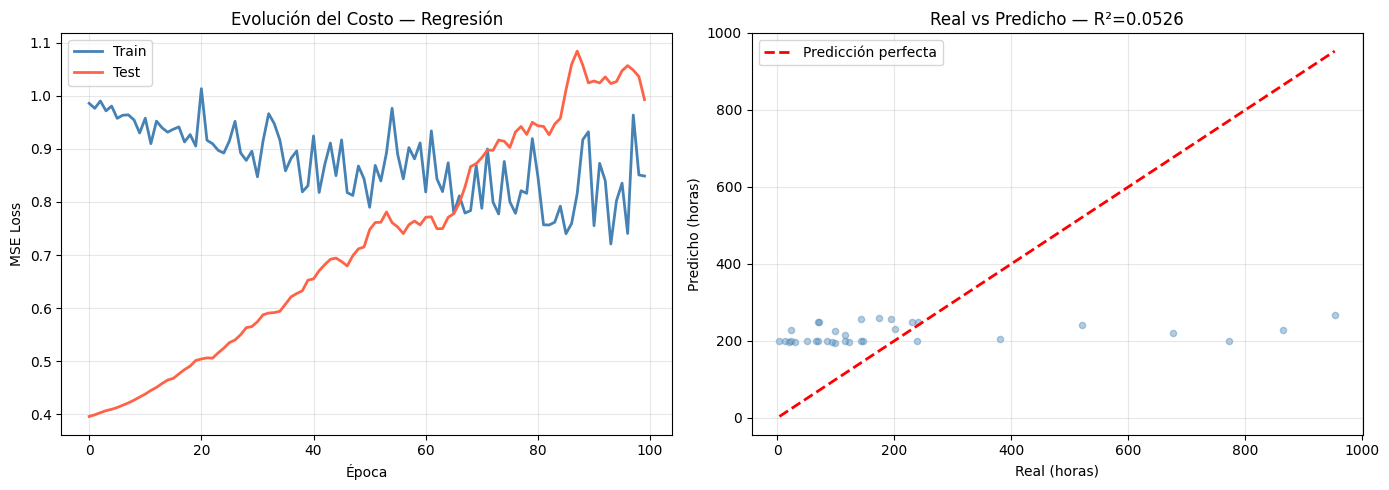

In [ ]:

modelo_reg.eval()
preds_reg = []

with torch.no_grad():
    X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
    preds_norm = modelo_reg(X_test_t).cpu().numpy()

preds_reg = preds_norm * sig_y + mu_y

rmse = np.sqrt(mean_squared_error(y_test_reg, preds_reg))
r2   = r2_score(y_test_reg, preds_reg)


print("  RESULTADOS — RED NEURONAL REGRESIÓN")

print(f"  RMSE: {rmse:.2f} horas")
print(f"  R²:   {r2:.4f}")


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hist_train_reg, label='Train', color='steelblue', lw=2)
axes[0].plot(hist_test_reg,  label='Test',  color='tomato',    lw=2)
axes[0].set_xlabel("Época"); axes[0].set_ylabel("MSE Loss")
axes[0].set_title("Evolución del Costo — Regresión")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_test_reg, preds_reg, alpha=0.4, s=20, color='steelblue')
lim = [min(y_test_reg.min(), preds_reg.min()), max(y_test_reg.max(), preds_reg.max())]
axes[1].plot(lim, lim, 'r--', lw=2, label='Predicción perfecta')
axes[1].set_xlabel("Real (horas)"); axes[1].set_ylabel("Predicho (horas)")
axes[1].set_title(f"Real vs Predicho — R²={r2:.4f}")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()